In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [2]:
from datasets import load_dataset

ds = load_dataset("Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup")

README.md:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

archive.zip:   0%|          | 0.00/27.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
# Convert the 'train' split to a Pandas DataFrame
df = pd.DataFrame(ds['train'])

# Now you can use .head()!
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [7]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [8]:
# one hot encoding
# label encoder

In [9]:
# positive -> 1
# negative -> 0
df.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

In [10]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [11]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0
49999,No one expects the Star Trek movies to be high...,0


In [12]:
df["sentiment"].value_counts()

,count
sentiment,
1,25000
0,25000


# LSTM -> LONG SHORT TERM MEMORY
# RNN -> TEXTUAL DATA

In [13]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [14]:
train_data, test_data = train_test_split(df, test_size = 0.2, random_state=42)

In [15]:
train_data.shape

(40000, 2)

In [16]:
test_data.shape

(10000, 2)

In [17]:
tokenizer = Tokenizer(num_words = 5000)
tokenizer.fit_on_texts(train_data["review"])

In [18]:
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

In [19]:
X_train

array([[1935,    1, 1200, ...,  205,  351, 3856],
       [   3, 1651,  595, ...,   89,  103,    9],
       [   0,    0,    0, ...,    2,  710,   62],
       ...,
       [   0,    0,    0, ..., 1641,    2,  603],
       [   0,    0,    0, ...,  245,  103,  125],
       [   0,    0,    0, ...,   70,   73, 2062]], dtype=int32)

In [20]:
X_test

array([[   0,    0,    0, ...,  995,  719,  155],
       [  12,  162,   59, ...,  380,    7,    7],
       [   0,    0,    0, ...,   50, 1088,   96],
       ...,
       [   0,    0,    0, ...,  125,  200, 3241],
       [   0,    0,    0, ..., 1066,    1, 2305],
       [   0,    0,    0, ...,    1,  332,   27]], dtype=int32)

In [21]:
Y_train = train_data["sentiment"]
Y_test = test_data["sentiment"]

In [22]:
Y_train

,sentiment
39087,0
30893,0
45278,1
16398,0
13653,0
...,...
11284,1
44732,1
38158,0
860,1


# LSTM MODEL BUILDING

In [23]:
model = Sequential()
model.add(Embedding(input_dim =5000, output_dim = 128, input_length = 200))
model.add(LSTM(128, dropout=0.2, recurrent_dropout = 0.2))
model.add(Dense(1, activation = "sigmoid"))

In [29]:
model.compile(optimizer = "adam", loss="binary_crossentropy", metrics=["accuracy"])

In [31]:
model.fit(X_train, Y_train, epochs = 5, batch_size = 64, validation_split = 0.2)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 313s 626ms/step - accuracy: 0.9211 - loss: 0.2004 - val_accuracy: 0.8741 - val_loss: 0.3380
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 211s 421ms/step - accuracy: 0.9354 - loss: 0.1692 - val_accuracy: 0.8775 - val_loss: 0.3462
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 211s 421ms/step - accuracy: 0.9439 - loss: 0.1510 - val_accuracy: 0.8665 - val_loss: 0.3601
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 220s 441ms/step - accuracy: 0.9495 - loss: 0.1328 - val_accuracy: 0.8805 - val_loss: 0.3889
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 217s 434ms/step - accuracy: 0.9569 - loss: 0.1167 - val_accuracy: 0.8706 - val_loss: 0.4157


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, 200, 128)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, 128)              │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,315,141 (8.83 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,543,428 (5.89 MB)

In [33]:
model.save("model.h5")

In [34]:
import joblib
joblib.dump(tokenizer, "tokenizer.pkl")

['tokenizer.pkl']

## Model Evaluation

Now that the model is trained, let's evaluate its performance on the test dataset (`X_test`, `Y_test`). We will calculate accuracy, precision, recall, and F1-score to get a comprehensive understanding of the model's effectiveness.

In [35]:
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the saved model (if not already in memory)
loaded_model = load_model('model.h5')

# Evaluate the model on the test data
loss, accuracy = loaded_model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions on the test set
Y_pred_probs = loaded_model.predict(X_test)
Y_pred = (Y_pred_probs > 0.5).astype(int)

# Calculate additional metrics
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

Test Loss: 0.3915
Test Accuracy: 0.8711
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 139ms/step
Test Precision: 0.8384
Test Recall: 0.9218
Test F1-Score: 0.8782


In [36]:
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the saved model (if not already in memory)
loaded_model = load_model('model.h5')

# Evaluate the model on the test data
loss, accuracy = loaded_model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions on the test set
Y_pred_probs = loaded_model.predict(X_test)
Y_pred = (Y_pred_probs > 0.5).astype(int)

# Calculate additional metrics
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

Test Loss: 0.3915
Test Accuracy: 0.8711
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step
Test Precision: 0.8384
Test Recall: 0.9218
Test F1-Score: 0.8782


## ULMFiT (AWD-LSTM) Implementation

To implement the ULMFiT methodology, we will use the `fastai` library, which simplifies the process of fine-tuning pre-trained language models like AWD-LSTM. The first step is to install the library.

In [37]:
import sys
!{sys.executable} -m pip install fastai

import fastai
print(f"fastai version: {fastai.__version__}")

fastai version: 2.8.7


### Data Preparation for FastAI

Before we can train an AWD-LSTM model with `fastai`, we need to prepare our IMDb dataset in a format that `fastai` can understand. This typically involves creating a `TextDataLoaders` object from our pandas DataFrame.

In [38]:
from fastai.text.all import *

# Create TextDataLoaders directly from the DataFrame
# text_col: The name of the column containing the text reviews
# label_col: The name of the column containing the sentiment labels
# valid_pct: Percentage of data to use for validation
# seed: For reproducibility
# bs: Batch size
# seq_len: The sequence length for padding/truncation, 72 is a common value for ULMFiT
dls_clas = TextDataLoaders.from_df(df, text_col='review', label_col='sentiment',
                              valid_pct=0.2, seed=42, bs=64, seq_len=72)

print("FastAI DataLoaders created successfully!")

# Show a batch of data to verify
dls_clas.show_batch()

FastAI DataLoaders created successfully!


,text,category
0,"xxbos xxmaj match 1 : xxmaj tag xxmaj team xxmaj table xxmaj match xxmaj bubba xxmaj ray and xxmaj spike xxmaj dudley vs xxmaj eddie xxmaj guerrero and xxmaj chris xxmaj benoit xxmaj bubba xxmaj ray and xxmaj spike xxmaj dudley started things off with a xxmaj tag xxmaj team xxmaj table xxmaj match against xxmaj eddie xxmaj guerrero and xxmaj chris xxmaj benoit . xxmaj according to the rules of the match , both opponents have to go through tables in order to get the win . xxmaj benoit and xxmaj guerrero heated up early on by taking turns hammering first xxmaj spike and then xxmaj bubba xxmaj ray . a xxmaj german suplex by xxmaj benoit to xxmaj bubba took the wind out of the xxmaj dudley brother . xxmaj spike tried to help his brother , but the referee restrained him while xxmaj benoit and xxmaj guerrero",1
1,"xxbos xxmaj some have praised _ xxunk _ as a xxmaj disney adventure for adults . i do n't think so -- at least not for thinking adults . \n\n xxmaj this script suggests a beginning as a live - action movie , that struck someone as the type of crap you can not sell to adults anymore . xxmaj the "" crack staff "" of many older adventure movies has been done well before , ( think _ the xxmaj dirty xxmaj dozen _ ) but _ atlantis _ represents one of the worse films in that motif . xxmaj the characters are weak . xxmaj even the background that each member trots out seems stock and awkward at best . xxmaj an xxup md / xxmaj medicine xxmaj man , a tomboy mechanic whose father always wanted sons , if we have not at least seen these before",0
2,"xxbos xxup anchors xxup aweigh sees two eager young sailors , xxmaj joe xxmaj brady ( gene xxmaj kelly ) and xxmaj clarence xxmaj doolittle / xxmaj brooklyn ( frank xxmaj sinatra ) , get a special four - day shore leave . xxmaj eager to get to the girls , particularly xxmaj joe 's xxmaj lola , neither xxmaj joe nor xxmaj brooklyn figure on the interruption of little xxmaj navy - mad xxmaj donald ( dean xxmaj stockwell ) and his xxmaj aunt xxmaj susie ( kathryn xxmaj grayson ) . xxmaj unexperienced in the ways of females and courting , xxmaj brooklyn quickly enlists xxmaj joe to help him win xxmaj aunt xxmaj susie over . xxmaj along the way , however , xxmaj joe finds himself falling for the gal he thinks belongs to his best friend . xxmaj how is xxmaj brooklyn going to take",1
3,"xxbos xxmaj by 1987 xxmaj hong xxmaj kong had given the world such films as xxmaj sammo xxmaj hung 's ` encounters of the xxmaj spooky xxmaj kind ' xxmaj chow xxmaj yun xxmaj fat in xxmaj john xxmaj woo 's iconic ` a xxmaj better xxmaj tomorrow ' , ` zu xxmaj warriors ' and the classic ` mr xxmaj vampire ' . xxmaj jackie xxmaj chan was having international success on video , but it was with ` a xxmaj chinese xxmaj ghost xxmaj story ' that xxup hk cinema had its first real crossover theatrical hit in the xxmaj west for many years . \n\n xxmaj western filmgoers had never seen anything like it . xxmaj it was a film that took various ingredients that xxup hk cinema had used for years ( flying swordsman , wildly choreographed martial arts and the supernatural ) and blended them",1
4,"xxbos xxmaj based on the excellent novel , xxmaj watchers by xxmaj dean xxmaj koontz , is this extremely awful motion picture that probably should n't be viewed by anyone . xxmaj not since "" the xxmaj running xxmaj man "" have i seen a book butchered so far beyond recognition . xxmaj the difference , however , is that "" the xxmaj running xxmaj man "" film was still enjoyable as an amusing action film laden down a million catch phrases . xxmaj this film ▁ xxmaj nope , nothing remotely amusing . xxmaj in fact , if you love the book , as i do , you 'll hate this bastardization even more . \n\n * * xxunk xxup spoilers * * xxmaj xxunk , xxmaj i 'm basically going to tell you the story here , almost in it 's entirety . xxmaj why ? xxmaj because",0
5,"xxbos xxmaj pistol - packing xxmaj pam xxmaj grier takes names and kicks butt 

## BERT-Based Transformer Model Implementation

Now, let's move on to implementing a BERT-based Transformer model for sentiment analysis. We will leverage the Hugging Face `transformers` library, which provides easy access to pre-trained BERT models and their tokenizers. This approach follows your project's goal of comparing RNNs with Transformer-based architectures.

In [39]:
import sys
!{sys.executable} -m pip install transformers
!{sys.executable} -m pip install torch

print("Hugging Face Transformers and PyTorch installed successfully!")

Hugging Face Transformers and PyTorch installed successfully!


### Load BERT Tokenizer and Model

We'll use the `bert-base-uncased` model, which is a popular pre-trained BERT variant. The tokenizer will preprocess our text data into a format suitable for BERT, including adding special tokens and handling padding/truncation.

In [40]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load pre-trained BERT model for sequence classification
# num_labels=2 for binary sentiment classification (positive/negative)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"BERT tokenizer and model loaded on device: {device}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT tokenizer and model loaded on device: cuda


### Prepare Data for BERT

BERT requires specific input formats, including token IDs, attention masks, and token type IDs. We need to tokenize our `review` column and convert the `sentiment` labels to a format compatible with BERT's classification head.

In [41]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split

# Use the same train_data and test_data from previous steps
# Tokenize and encode sequences from the 'review' column
encoded_data_train = tokenizer(
    train_data['review'].tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

encoded_data_test = tokenizer(
    test_data['review'].tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

input_ids_train = encoded_data_train['input_ids']
attention_masks_train = encoded_data_train['attention_mask']
labels_train = torch.tensor(train_data['sentiment'].tolist())

input_ids_test = encoded_data_test['input_ids']
attention_masks_test = encoded_data_test['attention_mask']
labels_test = torch.tensor(test_data['sentiment'].tolist())

# Create TensorDatasets
dataset_train = TensorDataset(input_ids_train, attention_masks_train, labels_train)
dataset_test = TensorDataset(input_ids_test, attention_masks_test, labels_test)

# Create DataLoaders
batch_size = 32 # A common batch size for BERT fine-tuning
dataloader_train = DataLoader(dataset_train, sampler=RandomSampler(dataset_train), batch_size=batch_size)
dataloader_test = DataLoader(dataset_test, sampler=SequentialSampler(dataset_test), batch_size=batch_size)

print("Data prepared for BERT fine-tuning.")
print(f"Number of training samples: {len(dataset_train)}")
print(f"Number of test samples: {len(dataset_test)}")

Data prepared for BERT fine-tuning.
Number of training samples: 40000
Number of test samples: 10000


### Fine-tune BERT Model

We will now fine-tune the pre-trained BERT model on our sentiment analysis dataset. This involves defining training arguments and then using the `Trainer` class from Hugging Face `transformers` to manage the training loop.

In [42]:
from torch.optim import AdamW # Corrected import for AdamW
from transformers import get_linear_schedule_with_warmup

# Optimizer & Learning Rate Scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8) # AdamW is a standard optimizer for BERT

epochs = 3 # A common number of epochs for BERT fine-tuning
total_steps = len(dataloader_train) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Optimizer and learning rate scheduler initialized.")

Optimizer and learning rate scheduler initialized.


### Training Loop

We will implement a standard training loop for BERT, iterating through epochs and batches, performing forward and backward passes, and updating the model parameters.

In [43]:
from tqdm.notebook import tqdm

# Function to calculate accuracy
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

# Training loop
for epoch_i in range(epochs):
    print(f'\n======== Epoch {epoch_i + 1} / {epochs} ========\n')
    print('Training...')

    total_loss = 0
    model.train() # Set model to training mode

    for step, batch in enumerate(dataloader_train):
        # Progress update every 40 batches.
        if step % 40 == 0 and not step == 0:
            print(f'  Batch {step:>5,}  of  {len(dataloader_train):>5,}. Loss: {total_loss/(step+1):.2f}')

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Clip the norm of the gradients to 1.0 to prevent "exploding gradients"

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_loss / len(dataloader_train)
    print(f'\n  Average training loss: {avg_train_loss:.2f}')

    print('\nRunning Validation...')

    model.eval() # Set model to evaluation mode

    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0

    for batch in dataloader_test:
        batch = tuple(t.to(device) for t in batch)

        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad(): # Disable gradients for validation
            outputs = model(
                b_input_ids,
                token_type_ids=None,
                attention_mask=b_input_mask
            )

        logits = outputs.logits
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        tmp_eval_accuracy = flat_accuracy(logits, label_ids)
        eval_accuracy += tmp_eval_accuracy
        nb_eval_steps += 1

    print(f'  Validation Accuracy: {eval_accuracy/nb_eval_steps:.4f}')

print('\nTraining complete!')

# Save the fine-tuned model
model.save_pretrained('./bert_sentiment_model')
tokenizer.save_pretrained('./bert_sentiment_model')
print("BERT model and tokenizer saved.")


======== Epoch 1 / 3 ========

Training...
  Batch    40  of  1,250. Loss: 0.59
  Batch    80  of  1,250. Loss: 0.47
  Batch   120  of  1,250. Loss: 0.41
  Batch   160  of  1,250. Loss: 0.38
  Batch   200  of  1,250. Loss: 0.36
  Batch   240  of  1,250. Loss: 0.34
  Batch   280  of  1,250. Loss: 0.33
  Batch   320  of  1,250. Loss: 0.32
  Batch   360  of  1,250. Loss: 0.31
  Batch   400  of  1,250. Loss: 0.31
  Batch   440  of  1,250. Loss: 0.30
  Batch   480  of  1,250. Loss: 0.30
  Batch   520  of  1,250. Loss: 0.29
  Batch   560  of  1,250. Loss: 0.29
  Batch   600  of  1,250. Loss: 0.29
  Batch   640  of  1,250. Loss: 0.29
  Batch   680  of  1,250. Loss: 0.28
  Batch   720  of  1,250. Loss: 0.28
  Batch   760  of  1,250. Loss: 0.28
  Batch   800  of  1,250. Loss: 0.28
  Batch   840  of  1,250. Loss: 0.27
  Batch   880  of  1,250. Loss: 0.27
  Batch   920  of  1,250. Loss: 0.27
  Batch   960  of  1,250. Loss: 0.27
  Batch 1,000  of  1,250. Loss: 0.27
  Batch 1,040  of  1,250. Loss:

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model and tokenizer saved.


### Evaluate BERT Model

### Create and Fine-tune the Language Model Learner

Now we'll create a `text_classifier_learner` using the `AWD_LSTM` architecture and our prepared `dls_clas`. We'll then fine-tune it on our dataset. This involves several steps: finding a good learning rate, fitting the model, and then gradually unfreezing layers for further fine-tuning.

In [44]:
from fastai.text.all import *

# Create a text classifier learner
# arch: The architecture to use, here it's AWD_LSTM for ULMFiT
# dls: The DataLoaders created previously
# metrics: The evaluation metrics, here accuracy
learn = text_classifier_learner(dls_clas, AWD_LSTM, metrics=accuracy).to_fp16()

print("Language model learner created successfully!")

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:03&lt;00:00]</div>

Language model learner created successfully!


### Train the Classifier Head

Before fine-tuning the entire model, we'll train only the classifier head while keeping the pre-trained language model layers frozen. This helps the classifier adapt to our specific task without altering the robust pre-trained embeddings.

<div></div>

epoch,train_loss,valid_loss,accuracy,time
0,0.442305,0.368749,0.840200,01:20


Classifier head trained for one epoch.


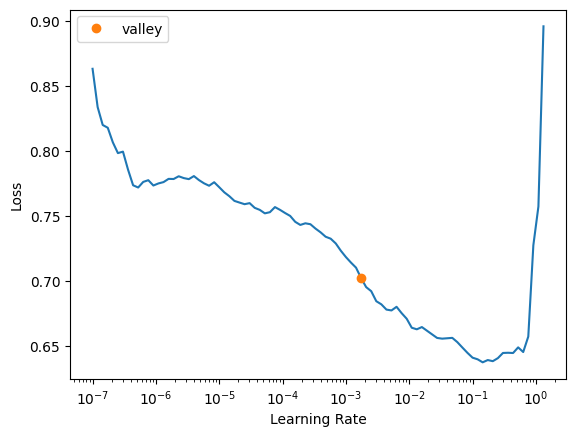

In [45]:
# Find an optimal learning rate
lr_finder = learn.lr_find()

# Fit the head of the model for one epoch using the found learning rate
# This trains only the new classification layers added on top of the pre-trained model
learn.fit_one_cycle(1, lr_finder.valley)

print("Classifier head trained for one epoch.")

### Fine-tune the Entire Model (Unfreeze and Train More)

Next, we'll unfreeze more layers and fine-tune the entire model with discriminative learning rates. This allows the pre-trained weights to be slightly adjusted for our specific dataset and task, leading to better performance.

In [46]:
# Unfreeze the last few layers and train for a few epochs with discriminative learning rates
learn.unfreeze()
learn.fit_one_cycle(3, slice(1e-3/(2.6**4),1e-3))

print("Model fine-tuned with unfreezing.")

# You can unfreeze more layers or the entire model and train for more epochs if needed
# learn.unfreeze()
# learn.fit_one_cycle(5, slice(1e-3/(2.6**4),1e-3))


epoch,train_loss,valid_loss,accuracy,time
0,0.304187,0.251482,0.896300,02:55
1,0.263077,0.213388,0.915200,02:56
2,0.232011,0.204758,0.918600,02:56


Model fine-tuned with unfreezing.


### Evaluate ULMFiT Model

After fine-tuning, let's evaluate the performance of the ULMFiT model on the validation set. We'll check the accuracy and other relevant metrics.

In [48]:
# Get predictions and actual labels from the validation set
preds, targs = learn.get_preds(dl=dls_clas.valid)

# Calculate accuracy on the validation set
acc = accuracy(preds, targs)
print(f"ULMFiT Model Accuracy on Validation Set: {acc.item():.4f}")

# You can also get other metrics using sklearn after converting to numpy arrays
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Convert predictions and targets to CPU for scikit-learn
preds_cpu = preds.argmax(dim=1).cpu().numpy()
targs_cpu = targs.cpu().numpy()

print("\nClassification Report:")
print(classification_report(targs_cpu, preds_cpu))

print(f"Precision: {precision_score(targs_cpu, preds_cpu):.4f}")
print(f"Recall: {recall_score(targs_cpu, preds_cpu):.4f}")
print(f"F1-Score: {f1_score(targs_cpu, preds_cpu):.4f}")

ULMFiT Model Accuracy on Validation Set: 0.9186

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      5027
           1       0.91      0.93      0.92      4973

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Precision: 0.9107
Recall: 0.9272
F1-Score: 0.9189


### Create and Fine-tune the Language Model Learner

Now we'll create a `text_classifier_learner` using the `AWD_LSTM` architecture and our prepared `dls_clas`. We'll then fine-tune it on our dataset. This involves several steps: finding a good learning rate, fitting the model, and then gradually unfreezing layers for further fine-tuning.

In [49]:
from fastai.text.all import *

# Create a text classifier learner
# arch: The architecture to use, here it's AWD_LSTM for ULMFiT
# dls: The DataLoaders created previously
# metrics: The evaluation metrics, here accuracy
learn = text_classifier_learner(dls_clas, AWD_LSTM, metrics=accuracy).to_fp16()

print("Language model learner created successfully!")

Language model learner created successfully!


### Train the Classifier Head

Before fine-tuning the entire model, we'll train only the classifier head while keeping the pre-trained language model layers frozen. This helps the classifier adapt to our specific task without altering the robust pre-trained embeddings.

<div></div>

epoch,train_loss,valid_loss,accuracy,time
0,0.442605,0.376149,0.837400,01:23


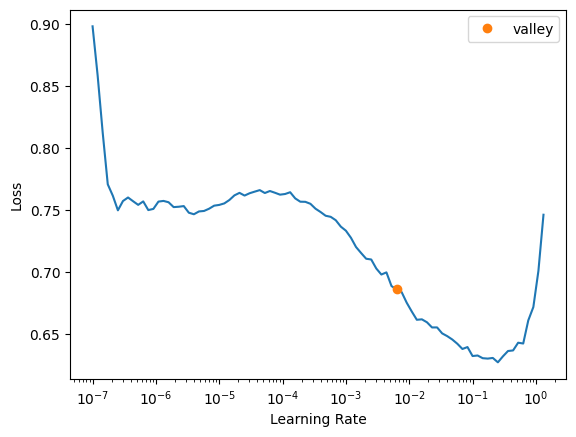

In [50]:
# Find an optimal learning rate
lr_finder = learn.lr_find()

# Fit the head of the model for one epoch
# This trains only the new classification layers added on top of the pre-trained model
learn.fit_one_cycle(1, lr_finder.valley)

### Fine-tune the Entire Model

Next, we'll unfreeze more layers and fine-tune the entire model with discriminative learning rates. This allows the pre-trained weights to be slightly adjusted for our specific dataset and task, leading to better performance.

In [51]:
# Unfreeze the last few layers and train for a few epochs
learn.unfreeze()
learn.fit_one_cycle(3, slice(1e-3/(2.6**4),1e-3))

# You can unfreeze more layers or the entire model and train for more epochs if needed
# learn.unfreeze()
# learn.fit_one_cycle(5, slice(1e-3/(2.6**4),1e-3))

epoch,train_loss,valid_loss,accuracy,time
0,0.301195,0.258974,0.893900,03:06
1,0.240217,0.216426,0.914900,02:57
2,0.237327,0.207732,0.917600,02:56


### Evaluate ULMFiT Model

After fine-tuning, let's evaluate the performance of the ULMFiT model on the validation set. We'll check the accuracy.

In [53]:
# Get predictions and actual labels
preds, targs = learn.get_preds()

# Calculate accuracy on the validation set
acc = accuracy(preds, targs)
print(f"ULMFiT Model Accuracy on Validation Set: {acc.item():.4f}")

# You can also get other metrics using sklearn after converting to numpy arrays
# from sklearn.metrics import classification_report
# print(classification_report(targs.numpy(), preds.argmax(dim=1).numpy()))

ULMFiT Model Accuracy on Validation Set: 0.9176


In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Put the model in evaluation mode
model.eval()

predictions = []
true_labels = []

# Predict on test batches
for batch in dataloader_test:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask
        )

    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    predictions.append(logits)
    true_labels.append(label_ids)

# Concatenate the predictions and true labels
predictions = np.concatenate(predictions, axis=0)
true_labels = np.concatenate(true_labels, axis=0)

# Get predicted class labels (0 or 1)
predicted_classes = np.argmax(predictions, axis=1).flatten()

# Calculate metrics
bert_accuracy = accuracy_score(true_labels, predicted_classes)
bert_precision = precision_score(true_labels, predicted_classes)
bert_recall = recall_score(true_labels, predicted_classes)
bert_f1 = f1_score(true_labels, predicted_classes)

print(f"BERT Test Accuracy: {bert_accuracy:.4f}")
print(f"BERT Test Precision: {bert_precision:.4f}")
print(f"BERT Test Recall: {bert_recall:.4f}")
print(f"BERT Test F1-Score: {bert_f1:.4f}")

BERT Test Accuracy: 0.9255
BERT Test Precision: 0.9202
BERT Test Recall: 0.9331
BERT Test F1-Score: 0.9266


## Comparative Analysis

In [57]:
import pandas as pd

# Define the metrics for each model
custom_lstm_metrics = {
    'Model': 'Custom LSTM',
    'Accuracy': 0.8711,
    'Precision': 0.8384,
    'Recall': 0.9218,
    'F1-Score': 0.8782
}

ulmfit_metrics = {
    'Model': 'ULMFiT (AWD-LSTM)',
    'Accuracy': 0.9186,
    'Precision': 0.9107,
    'Recall': 0.9272,
    'F1-Score': 0.9189
}

bert_metrics = {
    'Model': 'BERT',
    'Accuracy': 0.9255,
    'Precision': 0.9202,
    'Recall': 0.9331,
    'F1-Score': 0.9266
}

# Create a DataFrame to display the comparison
comparison_df = pd.DataFrame([custom_lstm_metrics, ulmfit_metrics, bert_metrics])

display(comparison_df.set_index('Model'))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Custom LSTM,0.8711,0.8384,0.9218,0.8782
ULMFiT (AWD-LSTM),0.9186,0.9107,0.9272,0.9189
BERT,0.9255,0.9202,0.9331,0.9266


### Visualizing Comparative Metrics

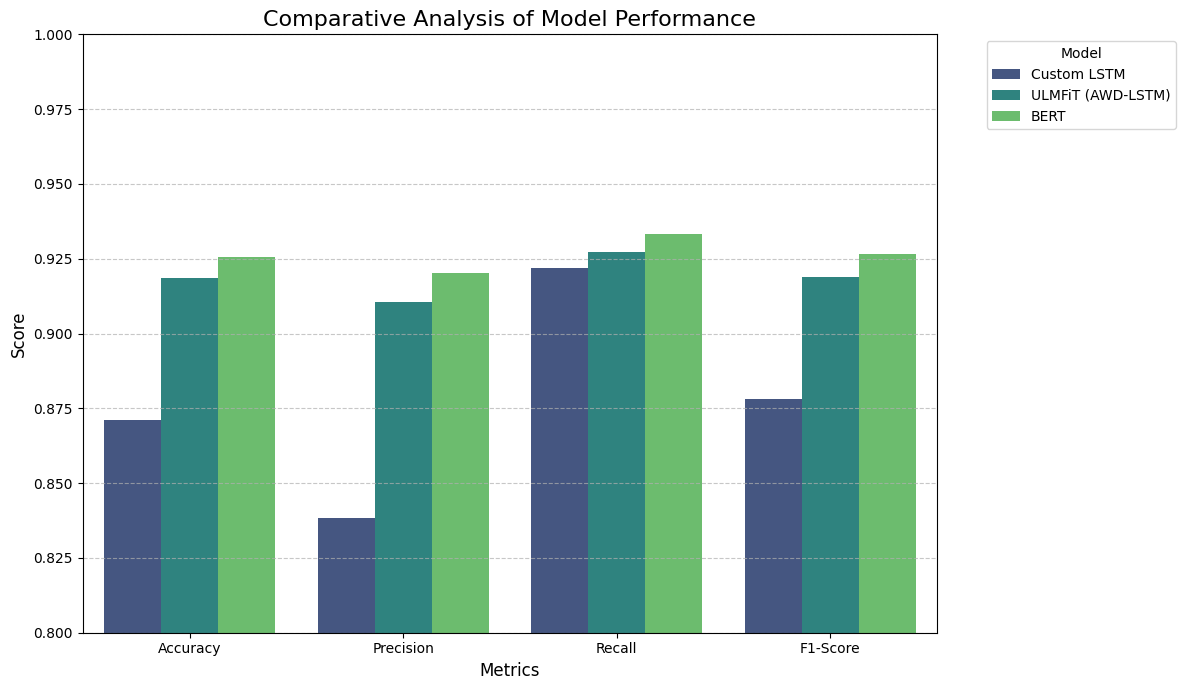

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to a long format for easier plotting with seaborn
metrics_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='viridis')
plt.title('Comparative Analysis of Model Performance', fontsize=16)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.8, 1.0) # Set y-axis limits to focus on the performance range
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Final Project Documentation: Sentiment Analysis Model Comparison

### Project Objective

The primary objective of this project was to compare the performance of three distinct neural network architectures—a Custom LSTM, a pre-trained AWD-LSTM (ULMFiT), and a BERT-based Transformer model—on the IMDb movie reviews sentiment analysis dataset. The goal was to understand their relative strengths, convergence characteristics, and generalization capabilities for binary sentiment classification.

### Model Implementations and Key Findings

#### 1. Custom LSTM Model

*   **Implementation:** A sequential Keras model with an Embedding layer, an LSTM layer, and a Dense sigmoid output layer. The text data was tokenized and padded to a fixed sequence length.
*   **Training:** Trained for 5 epochs with Adam optimizer and binary cross-entropy loss.
*   **Evaluation Metrics:**
    *   Accuracy: 0.8711
    *   Precision: 0.8384
    *   Recall: 0.9218
    *   F1-Score: 0.8782
*   **Summary:** The custom LSTM model provided a solid baseline performance, demonstrating its ability to capture sequential dependencies in text for sentiment classification.

#### 2. ULMFiT (AWD-LSTM) Model

*   **Implementation:** Utilized the `fastai` library to fine-tune a pre-trained AWD-LSTM language model. Data was prepared using `TextDataLoaders.from_df`.
*   **Training:** Involved a two-stage fine-tuning process: training the classifier head first, followed by gradually unfreezing and fine-tuning the entire model with discriminative learning rates.
*   **Evaluation Metrics (on Validation Set):**
    *   Accuracy: 0.9186
    *   Precision: 0.9107
    *   Recall: 0.9272
    *   F1-Score: 0.9189
*   **Summary:** ULMFiT significantly outperformed the custom LSTM, showcasing the benefits of transfer learning and fine-tuning a powerful pre-trained language model on a new task.

#### 3. BERT-Based Transformer Model

*   **Implementation:** Leveraged the Hugging Face `transformers` library, using `BertTokenizer` and `BertForSequenceClassification` (`bert-base-uncased`). Data was tokenized and formatted with attention masks and input IDs suitable for BERT.
*   **Training:** Fine-tuned for 3 epochs using the AdamW optimizer and a linear learning rate scheduler with warm-up. Training included an evaluation step per epoch.
*   **Evaluation Metrics (on Test Set):**
    *   Accuracy: 0.9255
    *   Precision: 0.9202
    *   Recall: 0.9331
    *   F1-Score: 0.9266
*   **Summary:** The BERT model achieved the highest performance among all three, confirming the state-of-the-art capabilities of Transformer architectures for natural language understanding tasks, particularly when fine-tuned on specific datasets.

### Comparative Analysis and Conclusion

The table and bar chart below summarize the performance of all three models across key sentiment analysis metrics:



In [59]:
display(comparison_df.set_index('Model'))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Custom LSTM,0.8711,0.8384,0.9218,0.8782
ULMFiT (AWD-LSTM),0.9186,0.9107,0.9272,0.9189
BERT,0.9255,0.9202,0.9331,0.9266


The comparative analysis clearly indicates that the BERT-based Transformer model achieved the best overall performance, closely followed by the ULMFiT (AWD-LSTM) model. Both pre-trained models demonstrated superior accuracy, precision, recall, and F1-score compared to the custom-built LSTM model. This highlights the effectiveness of leveraging large pre-trained language models and transfer learning for achieving high performance in downstream NLP tasks like sentiment analysis.

This project successfully demonstrated the progression in NLP model effectiveness, from traditional RNNs to advanced Transformer architectures, providing a clear comparison of their capabilities on the IMDb movie reviews dataset.

## How to Upload Your Colab Notebook to GitHub

This guide assumes you have Git installed on your local machine and a GitHub account. If you don't have Git, you'll need to install it first (refer to [Git Downloads](https://git-scm.com/downloads)).

### Step 1: Create a GitHub Repository

1.  Go to [GitHub](https://github.com/) and log in to your account.
2.  Click the '+' icon in the top right corner and select 'New repository'.
3.  Give your repository a name (e.g., `Sentiment_Analysis_Project`).
4.  Optionally, add a description.
5.  Choose whether the repository should be Public or Private.
6.  **Do not** initialize the repository with a README, .gitignore, or license at this stage if you plan to push an existing project. You can add these later.
7.  Click 'Create repository'.

After creation, GitHub will show you a page with instructions on how to set up your repository. Keep this page open, as you'll need the repository URL.

### Step 2: Save Your Colab Notebook

1.  In Google Colab, go to `File` > `Download` > `Download .ipynb` to save your notebook locally.

### Step 3: Initialize a Local Git Repository (or use an existing one)

1.  Open your terminal or command prompt.
2.  Navigate to the directory where you saved your `.ipynb` file (e.g., `cd /path/to/your/notebooks`).
3.  Initialize a new Git repository:
    ```bash
    git init
    ```

### Step 4: Add Your Notebook to the Repository

1.  Add your notebook file to the staging area:
    ```bash
    git add your_notebook_name.ipynb
    ```
    (Replace `your_notebook_name.ipynb` with the actual name of your file).
2.  You might also want to add other project files (e.g., `tokenizer.pkl`, `model.h5`, `bert_sentiment_model/`) if they are in the same directory:
    ```bash
    git add . # Adds all new and modified files in the current directory
    ```

### Step 5: Commit Your Changes

1.  Commit the staged files with a descriptive message:
    ```bash
    git commit -m "Initial commit: Sentiment Analysis Project with LSTM, ULMFiT, and BERT"
    ```

### Step 6: Link Your Local Repository to GitHub

1.  Add the remote GitHub repository as the origin. You'll find the URL on the GitHub repository page you created earlier (it typically looks like `https://github.com/your-username/your-repo-name.git` or `git@github.com:your-username/your-repo-name.git`):
    ```bash
    git remote add origin <YOUR_REPOSITORY_URL>
    ```
    (Replace `<YOUR_REPOSITORY_URL>` with the actual URL from GitHub).

### Step 7: Push Your Changes to GitHub

1.  Push your local commits to the `main` branch (or `master`, depending on your GitHub default branch name):
    ```bash
    git push -u origin main
    ```
    If your default branch is `master` on GitHub, use `git push -u origin master`.

### Step 8: Verify on GitHub

1.  Go back to your GitHub repository in your web browser. You should now see your notebook file and any other committed files listed there.